# 03 描述性统计、可视化与回归分析

> **作业**：P02 金融数据获取、管理与初步分析  
> **姓名**：李泽欣  
> **日期**：2026-04-07

---

## 概述

| 部分 | 内容 |
|------|------|
| 第四部分 | 描述性统计与可视化（图 1-4 + 图 5 选做） |
| 第五部分 | CAPM 回归分析与讨论 |
| 附录 | AI 对话记录 |

In [25]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 150

PROJECT_ROOT = os.path.dirname(os.path.abspath('__file__'))
OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'output')
os.makedirs(OUTPUT_DIR, exist_ok=True)

STOCK_INFO = {
    '000001': ('平安银行', '银行'),
    '601398': ('工商银行', '银行'),
    '002594': ('比亚迪',   '汽车'),
    '601633': ('长城汽车', '汽车'),
    '000002': ('万科A',    '房地产'),
    '600519': ('贵州茅台', '白酒'),
    '000858': ('五粮液',   '白酒'),
    '601857': ('中国石油', '能源'),
    '000063': ('中兴通讯', '通讯'),
    '002352': ('顺丰控股', '物流'),
}

INDUSTRY_COLORS = {
    '银行': '#1f77b4', '汽车': '#ff7f0e', '房地产': '#2ca02c',
    '白酒': '#d62728', '能源': '#9467bd', '通讯': '#8c564b', '物流': '#e377c2',
}

print('环境准备完成')

环境准备完成


## 加载数据

In [26]:
stock_clean = pd.read_csv(os.path.join(PROJECT_ROOT, 'data/clean/stock_clean.csv'))
stock_clean['date'] = pd.to_datetime(stock_clean['date'])
stock_clean['code'] = stock_clean['code'].astype(str).str.zfill(6)

index_300 = pd.read_csv(os.path.join(PROJECT_ROOT, 'data/index/index_000300.csv'))
index_300['date'] = pd.to_datetime(index_300['date'])
index_300 = index_300[index_300['date'] >= '2020-01-01'].sort_values('date')
index_300['close'] = pd.to_numeric(index_300['close'], errors='coerce')

combined = pd.read_csv(os.path.join(PROJECT_ROOT, 'data/combined/combined_data.csv'))
combined['date'] = pd.to_datetime(combined['date'])

finance_df = pd.read_csv(os.path.join(PROJECT_ROOT, 'data/finance/finance_ratios.csv'))
finance_df['code'] = finance_df['code'].astype(str).str.zfill(6)

print(f'个股数据: {stock_clean.shape}')
print(f'沪深300:  {index_300.shape}')
print(f'综合数据: {combined.shape}')
print(f'财务数据: {finance_df.shape}')
print(f'财务 code 示例: {finance_df["code"].unique()[:3]}')

个股数据: (15120, 10)
沪深300:  (1512, 7)
综合数据: (15120, 15)
财务数据: (100, 6)
财务 code 示例: <ArrowStringArray>
['000001', '601398', '002594']
Length: 3, dtype: str


In [27]:
# 确保 code 列是字符串类型
stock_clean['code'] = stock_clean['code'].astype(str).str.zfill(6)

close_wide = stock_clean.pivot_table(index='date', columns='code', values='close')
returns_wide = np.log(close_wide / close_wide.shift(1)).dropna()

index_300_daily = index_300.set_index('date')[['close']].rename(columns={'close': '000300'})
index_300_daily['return_300'] = np.log(index_300_daily['000300'] / index_300_daily['000300'].shift(1))

print(f'收盘价宽表: {close_wide.shape}')
print(f'收益率宽表: {returns_wide.shape}')
print(f'列名示例: {close_wide.columns[:3].tolist()}')

收盘价宽表: (1512, 10)
收益率宽表: (1511, 10)
列名示例: ['000001', '000002', '000063']


---

## 第四部分：描述性统计与可视化

### 4.1 基本统计量

计算 10 只股票日对数收益率的描述性统计量。

In [28]:
def max_drawdown(prices):
    cummax = prices.cummax()
    drawdown = (prices - cummax) / cummax
    return drawdown.min()

stat_rows = []
for code in returns_wide.columns:
    r = returns_wide[code].dropna()
    name, industry = STOCK_INFO[code]
    p = close_wide[code].dropna()
    stat_rows.append({
        '股票': f'{name}({code})',
        '行业': industry,
        '年化均值': f'{r.mean() * 252:.2%}',
        '年化波动率': f'{r.std() * np.sqrt(252):.2%}',
        '偏度': f'{r.skew():.3f}',
        '峰度': f'{r.kurtosis():.3f}',
        '最大回撤': f'{max_drawdown(p):.2%}',
    })

stat_df = pd.DataFrame(stat_rows)
print('10 只股票日收益率描述性统计：')
display(stat_df)

10 只股票日收益率描述性统计：


,股票,行业,年化均值,年化波动率,偏度,峰度,最大回撤
0,平安银行(000001),银行,-6.49%,29.94%,-0.192,8.603,-62.35%
1,万科A(000002),房地产,-31.52%,36.41%,0.654,3.257,-86.10%
2,中兴通讯(000063),通讯,0.14%,42.62%,0.309,2.482,-61.87%
3,五粮液(000858),白酒,-1.15%,34.57%,0.087,3.308,-66.09%
4,顺丰控股(002352),物流,1.71%,32.46%,0.376,3.539,-70.77%
5,比亚迪(002594),汽车,31.44%,43.32%,0.302,2.088,-52.54%
6,贵州茅台(600519),白酒,6.66%,27.72%,0.262,3.606,-47.48%
7,工商银行(601398),银行,9.66%,16.27%,0.458,5.852,-20.20%
8,长城汽车(601633),汽车,15.02%,45.23%,0.449,2.117,-70.38%
9,中国石油(601857),能源,16.91%,29.27%,0.221,5.178,-32.47%


**统计量解读**：

本次样本中，收益与风险分化非常明显。收益率最高的是 **比亚迪**，年化均值约 **31.44%**，其次是 **中国石油**（**16.91%**）和 **长城汽车**（**15.02%**）；表现最弱的是 **万科A**，年化均值约 **-31.52%**，其最大回撤也达到 **-86.10%**，说明房地产行业在样本期内承受了持续而深度的下行压力。

从波动率看，**长城汽车**（**45.23%**）、**比亚迪**（**43.32%**）和 **中兴通讯**（**42.62%**）属于高波动资产，而 **工商银行** 的年化波动率仅 **16.27%**，明显更具防御性。多数股票峰度为正，尤其是 **平安银行**（峰度 **8.603**）和 **工商银行**（峰度 **5.852**），说明收益率分布普遍具有尖峰厚尾特征，极端波动出现频率高于正态分布假设。


### 4.2 可视化

#### 图 1：归一化收盘价走势图

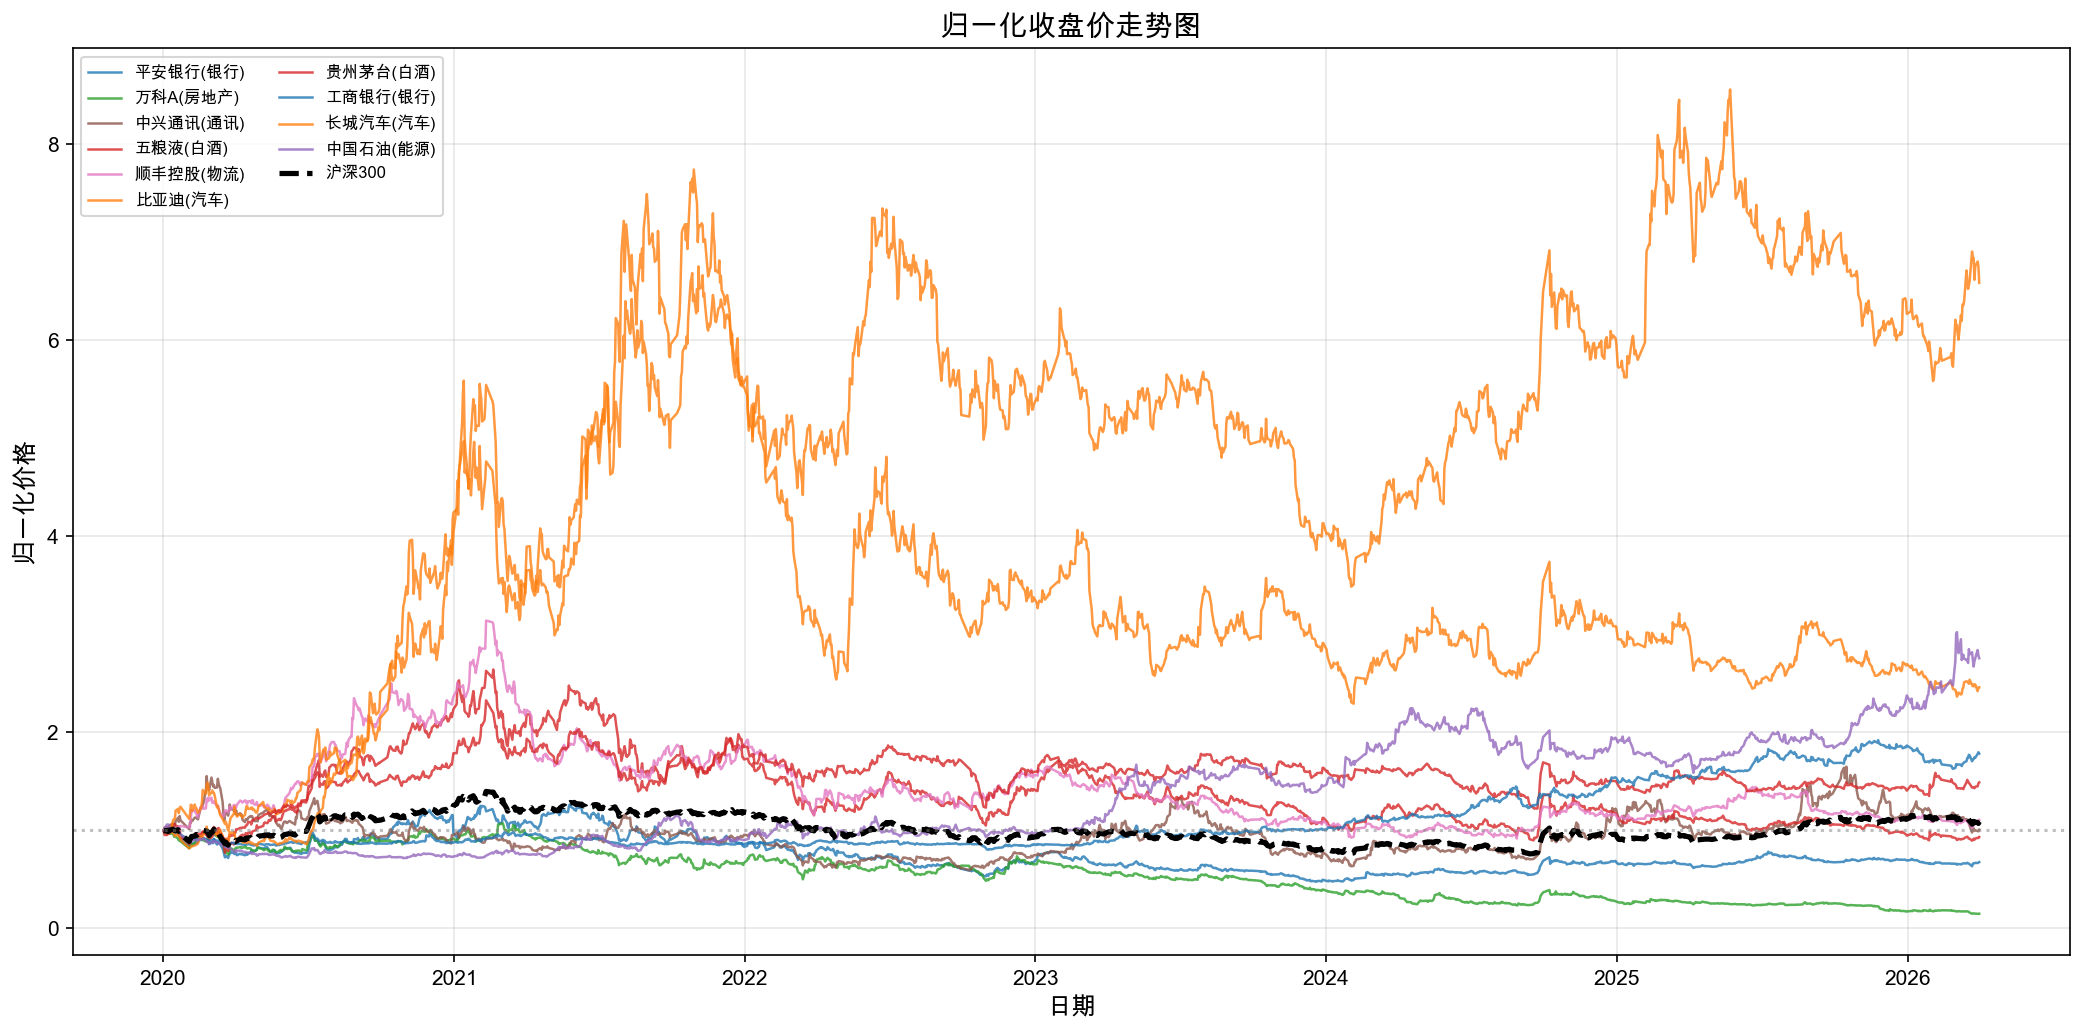

OK 图1已保存


In [29]:
fig, ax = plt.subplots(figsize=(14, 7))
norm_close = close_wide / close_wide.iloc[0]
for code in norm_close.columns:
    name, industry = STOCK_INFO[code]
    ax.plot(norm_close.index, norm_close[code], label=f'{name}({industry})',
            color=INDUSTRY_COLORS[industry], alpha=0.8, linewidth=1.2)

idx_norm = index_300_daily['000300'] / index_300_daily['000300'].iloc[0]
ax.plot(idx_norm.index, idx_norm.values, label='沪深300',
        color='black', linewidth=2.5, linestyle='--')
ax.axhline(y=1, color='gray', linestyle=':', alpha=0.5)
ax.set_title('归一化收盘价走势图', fontsize=14, fontweight='bold')
ax.set_xlabel('日期', fontsize=12)
ax.set_ylabel('归一化价格', fontsize=12)
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig1_normalized_price.png'), dpi=150, bbox_inches='tight')
plt.show()
print('OK 图1已保存')

**图 1 解读**：

归一化价格图显示，不同行业股票在 2020-2026 年间的长期表现差异很大。**比亚迪**的累计涨幅最高，区间总回报约 **558.76%**，明显领先其他股票；**中国石油**和 **长城汽车**也分别取得约 **175.70%** 和 **146.12%** 的累计涨幅，说明能源与汽车板块在样本期内具有较强弹性。

与之形成鲜明对比的是 **万科A**，区间累计回报约 **-84.89%**，在图中呈现持续下行趋势；**平安银行**和 **五粮液** 也分别录得 **-32.22%** 和 **-6.68%** 的负收益。沪深 300 的走势位于这些个股之间，更能反映市场整体中枢，而非极端赢家或输家。

---


#### 图 2：日收益率分布图（2 行 x 5 列）

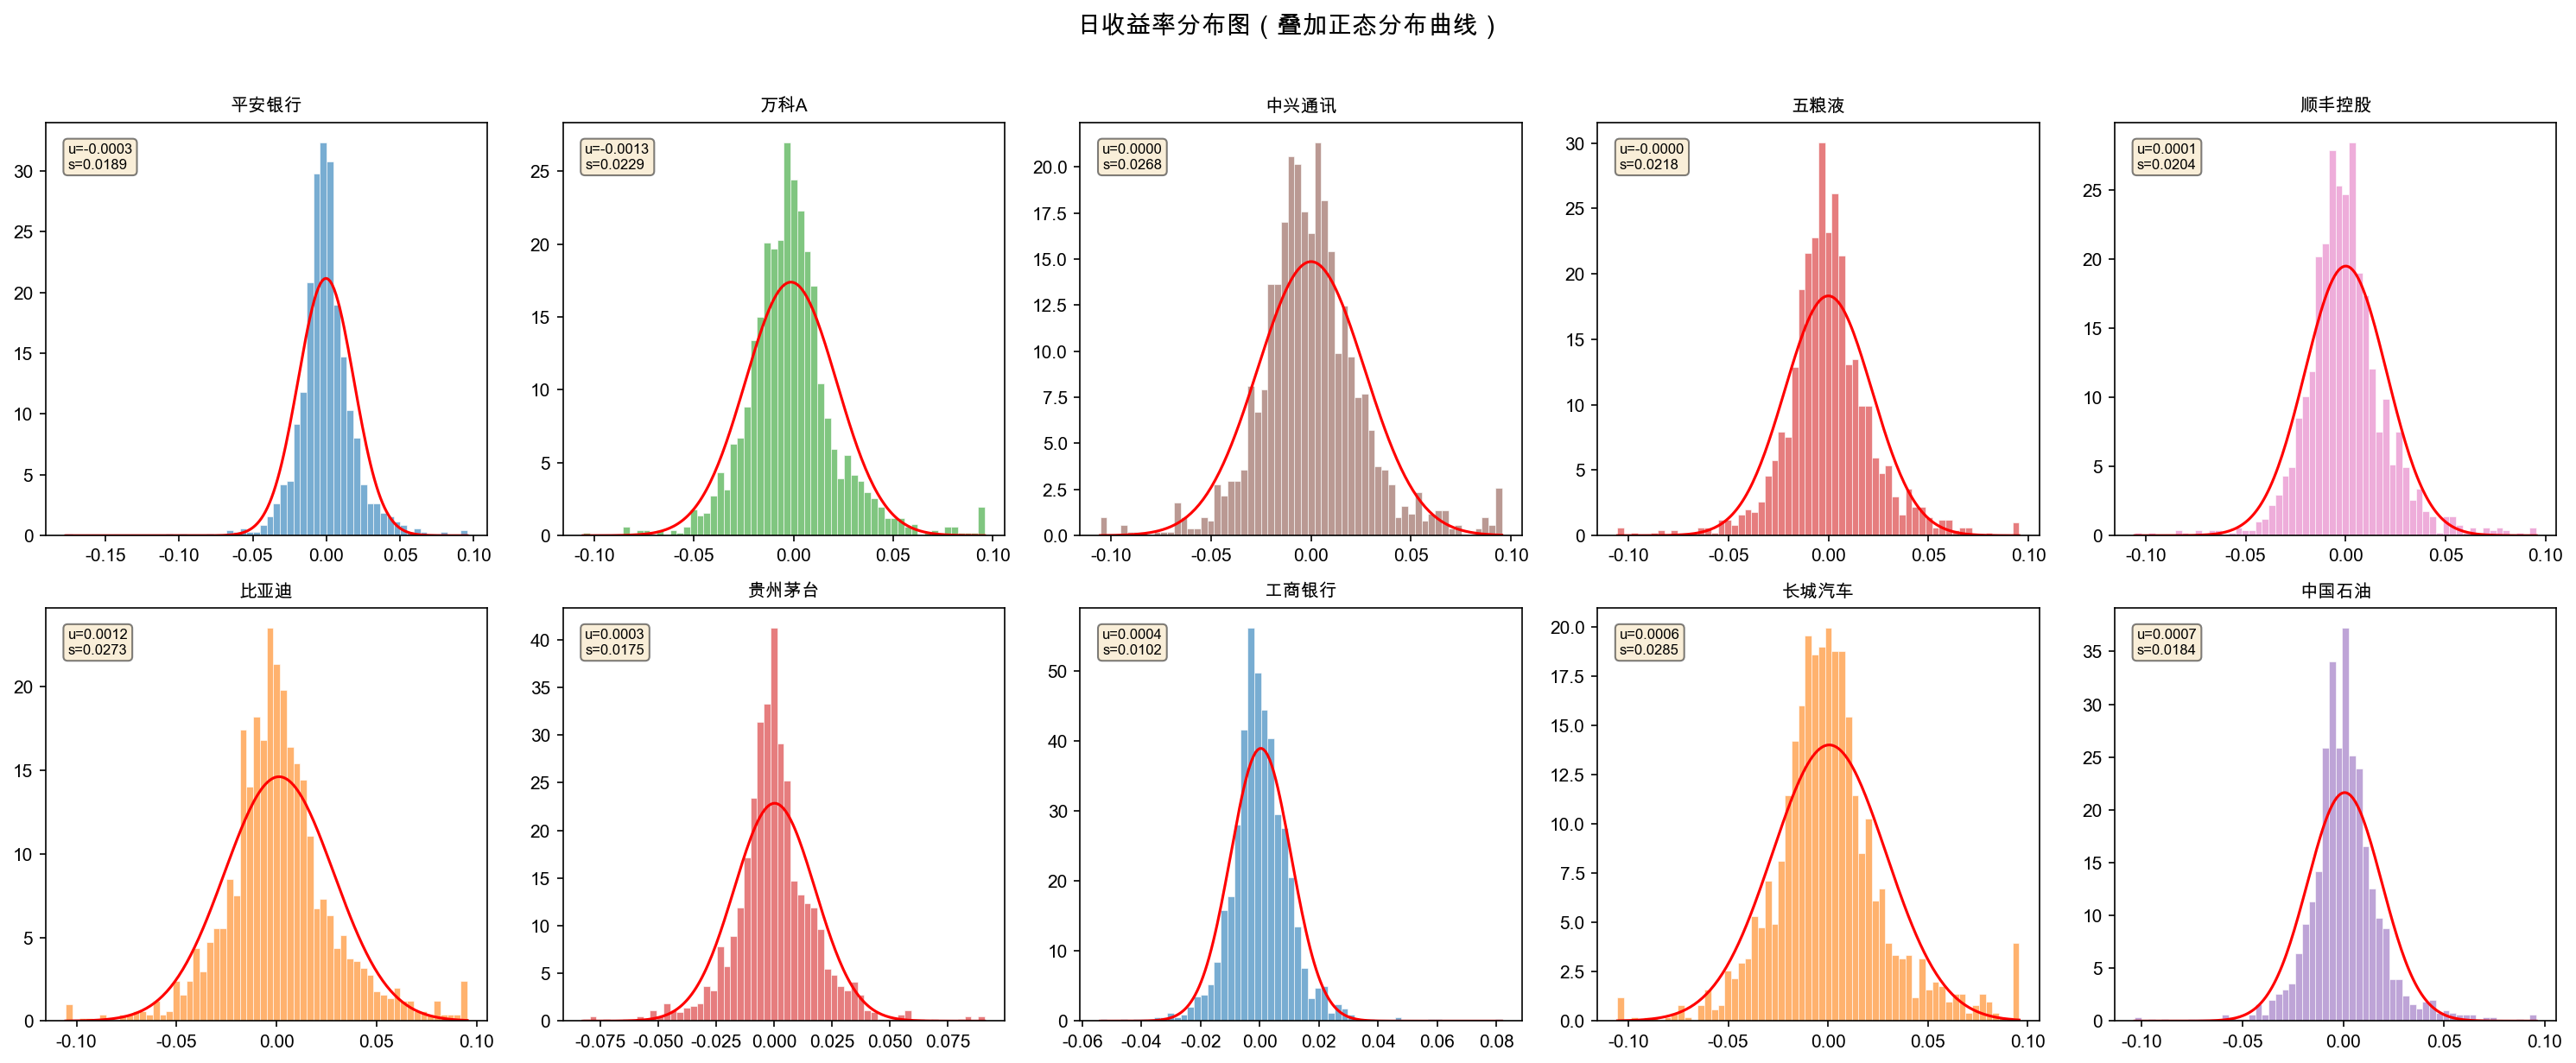

OK 图2已保存


In [30]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for i, code in enumerate(returns_wide.columns):
    ax = axes[i]
    r = returns_wide[code].dropna()
    name, industry = STOCK_INFO[code]
    ax.hist(r, bins=60, density=True, alpha=0.6,
            color=INDUSTRY_COLORS[industry], edgecolor='white', linewidth=0.5)
    mu, sigma = r.mean(), r.std()
    x = np.linspace(r.min(), r.max(), 200)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=1.5)
    ax.set_title(f'{name}', fontsize=10, fontweight='bold')
    ax.text(0.05, 0.95, f'u={mu:.4f}\ns={sigma:.4f}',
            transform=ax.transAxes, fontsize=8, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
fig.suptitle('日收益率分布图（叠加正态分布曲线）', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig2_return_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print('OK 图2已保存')

**图 2 解读**：

日收益率分布图表明，各股票的收益率都围绕 0 附近波动，但分布宽度差异明显。**工商银行** 的分布最集中，对应其较低的年化波动率；而 **比亚迪、长城汽车、中兴通讯** 的分布明显更宽，说明这些股票在日频层面的价格波动更剧烈。

从分布形态看，多数股票都不是标准正态分布，而是呈现一定程度的厚尾和偏态。例如 **平安银行**略带负偏且峰度很高，说明其日收益率更容易出现尾部冲击；**万科A**则表现出正偏但长期收益很差，说明个别阶段虽有反弹，但并没有改变整体下行趋势。

---


#### 图 3：收益率相关系数热力图

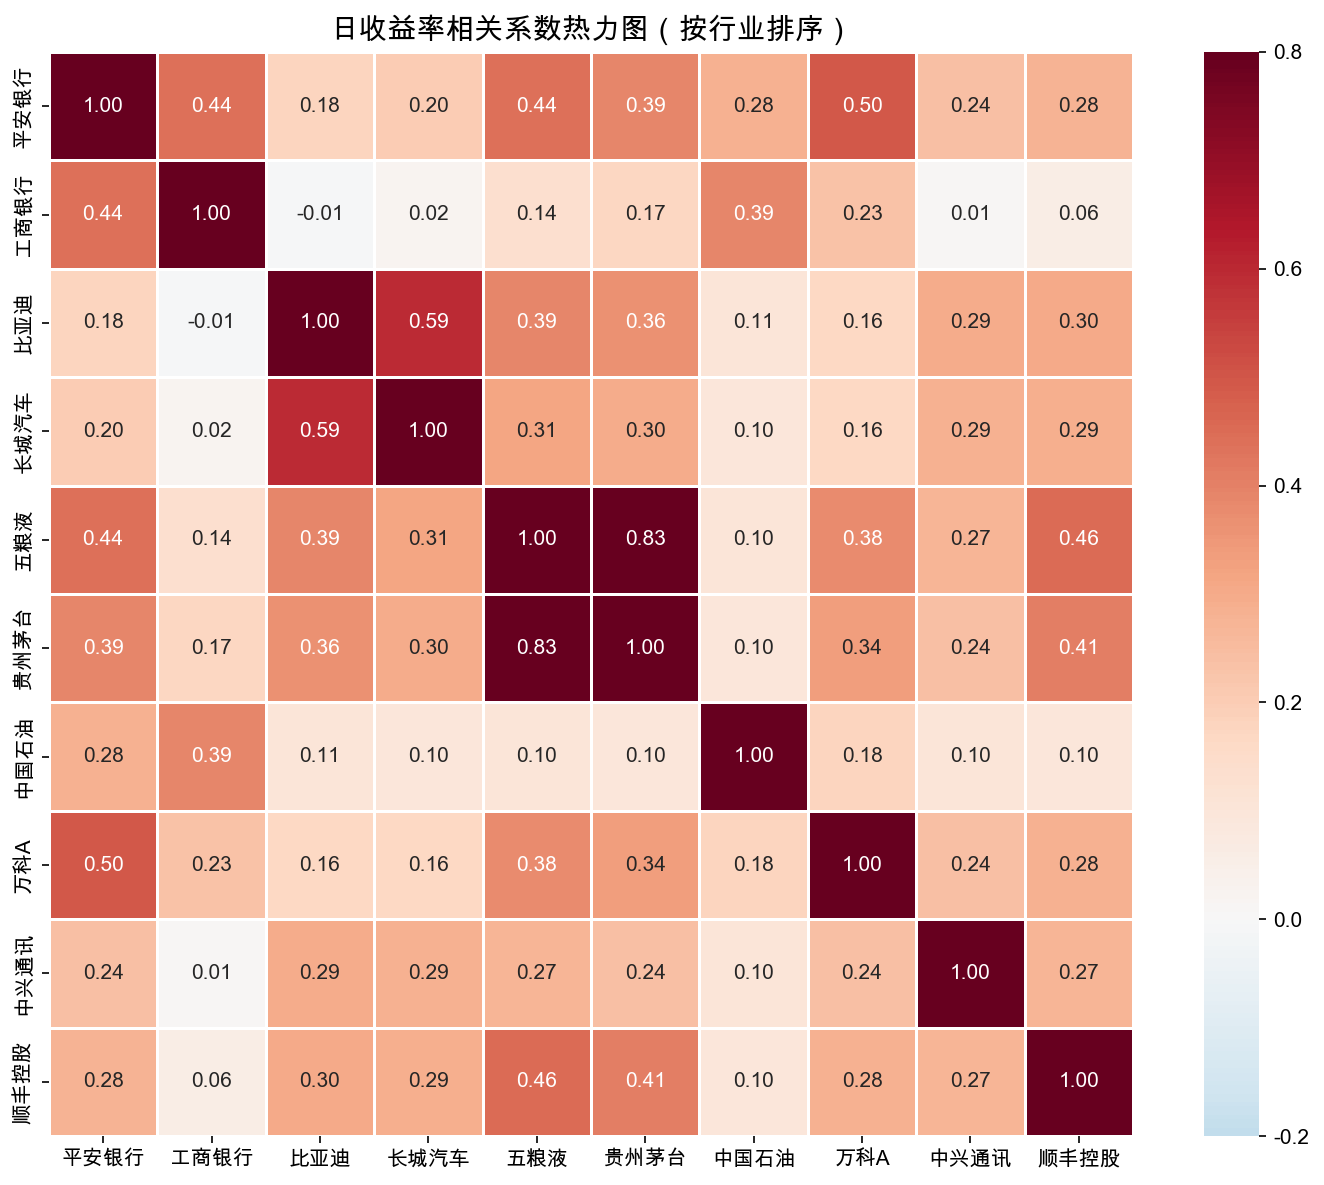

OK 图3已保存


In [31]:
industry_order = ['银行', '汽车', '白酒', '能源', '房地产', '通讯', '物流']
sorted_codes = sorted(returns_wide.columns,
                       key=lambda x: (industry_order.index(STOCK_INFO[x][1]), x))
returns_sorted = returns_wide[sorted_codes]
returns_sorted.columns = [STOCK_INFO[c][0] for c in sorted_codes]
corr_matrix = returns_sorted.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-0.2, vmax=0.8, square=True, linewidths=0.5, ax=ax)
ax.set_title('日收益率相关系数热力图（按行业排序）', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig3_correlation_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()
print('OK 图3已保存')

**图 3 解读**：

相关系数热力图中，最显著的行业内联动来自 **白酒板块**，其中 **五粮液-贵州茅台** 的相关系数高达 **0.835**，说明两者受共同消费景气和市场风格驱动的程度很高。汽车板块内部的 **比亚迪-长城汽车** 相关系数也达到 **0.595**，同样明显高于许多跨行业组合。

但并不是所有“同属大盘股”的股票都高度同步，例如 **比亚迪-工商银行** 的相关系数约为 **-0.005**，几乎不相关；**中兴通讯-工商银行** 相关系数也仅 **0.014**。这说明跨行业配置仍然具有分散风险的价值，而行业属性在解释相关性时比“是否都是权重股”更有帮助。

---


#### 图 4：CPI 同比 vs 沪深300月度收益率

In [32]:
# 计算沪深300月度收益率
index_monthly = index_300_daily['000300'].resample('ME').last()
index_monthly_ret = np.log(index_monthly / index_monthly.shift(1)).dropna()
index_monthly_ret = index_monthly_ret.to_frame('return_300')
index_monthly_ret['year_month'] = index_monthly_ret.index.to_period('M')

# 加载 CPI 数据（列名: 日期, 今值）
cpi_raw = pd.read_csv(os.path.join(PROJECT_ROOT, 'data/macro/macro_cpi.csv'))
print('CPI 列名:', cpi_raw.columns.tolist())

# 适配列名：优先匹配已知格式
if '日期' in cpi_raw.columns:
    cpi_raw['date'] = pd.to_datetime(cpi_raw['日期'], errors='coerce')
else:
    date_col = cpi_raw.columns[1] if len(cpi_raw.columns) > 1 else cpi_raw.columns[0]
    cpi_raw['date'] = pd.to_datetime(cpi_raw[date_col], errors='coerce')

if '今值' in cpi_raw.columns:
    cpi_raw['cpi'] = pd.to_numeric(cpi_raw['今值'], errors='coerce')
else:
    val_candidates = [c for c in cpi_raw.columns if any(k in c for k in ['同比', 'cpi', 'yoy', '全国', '今值'])]
    val_col = val_candidates[0] if val_candidates else cpi_raw.columns[2]
    cpi_raw['cpi'] = pd.to_numeric(cpi_raw[val_col], errors='coerce')

cpi_raw = cpi_raw.dropna(subset=['date', 'cpi'])
cpi_raw['year_month'] = cpi_raw['date'].dt.to_period('M')
cpi_monthly = cpi_raw[['year_month', 'cpi']].drop_duplicates('year_month')

merged = index_monthly_ret.merge(cpi_monthly, on='year_month', how='inner').dropna()
print(f'CPI 与沪深300月度数据合并: {len(merged)} 个月')
display(merged.head())

CPI 列名: ['商品', '日期', '今值', '预测值', '前值']
CPI 与沪深300月度数据合并: 67 个月


,return_300,year_month,cpi
0,-0.016076,2020-02,5.4
1,-0.066609,2020-03,5.2
2,0.059612,2020-04,4.3
3,-0.011711,2020-05,3.3
4,0.073982,2020-06,2.4


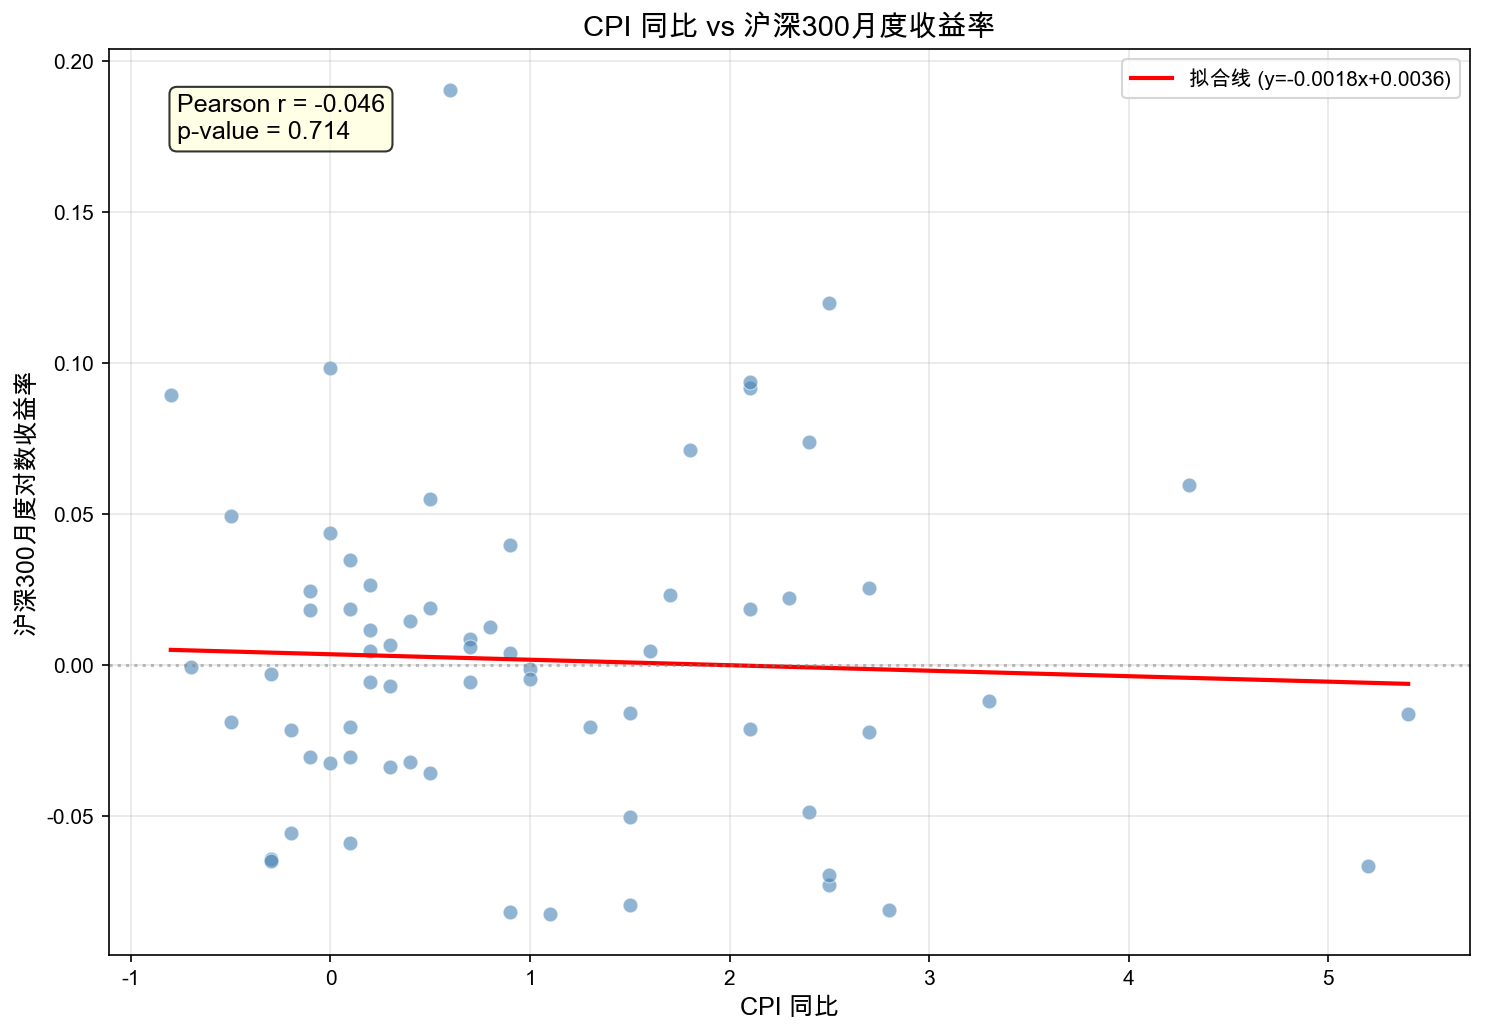

OK 图4已保存


In [33]:
fig, ax = plt.subplots(figsize=(10, 7))
x = merged['cpi'].values
y = merged['return_300'].values
ax.scatter(x, y, alpha=0.6, s=50, color='steelblue', edgecolors='white', linewidth=0.5)
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
x_fit = np.linspace(x.min(), x.max(), 100)
ax.plot(x_fit, slope * x_fit + intercept, 'r-', linewidth=2,
        label=f'拟合线 (y={slope:.4f}x+{intercept:.4f})')
ax.text(0.05, 0.95, f'Pearson r = {r_value:.3f}\np-value = {p_value:.3f}',
        transform=ax.transAxes, fontsize=12, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
ax.set_title('CPI 同比 vs 沪深300月度收益率', fontsize=14, fontweight='bold')
ax.set_xlabel('CPI 同比', fontsize=12)
ax.set_ylabel('沪深300月度对数收益率', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='gray', linestyle=':', alpha=0.5)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig4_cpi_vs_market.png'), dpi=150, bbox_inches='tight')
plt.show()
print('OK 图4已保存')

**图 4 解读**：

本次样本中，CPI 同比与沪深 300 月度收益率共成功匹配 **67 个月**，Pearson 相关系数约为 **-0.046**，接近于 0，表现为非常弱的负相关。这意味着在当前样本期内，单独使用 CPI 同比这一指标，很难对沪深 300 的月度涨跌给出强解释。

散点图中的拟合线斜率也为轻微负值，说明通胀上行阶段并没有稳定对应更高或更低的股市回报。更合理的解释是：股票市场同时受到增长预期、政策宽松程度、风险偏好等多重因素影响，CPI 只是其中一个宏观切面，而且其影响可能存在时滞。

---


#### 图 5（选做）：ROE 跨公司对比

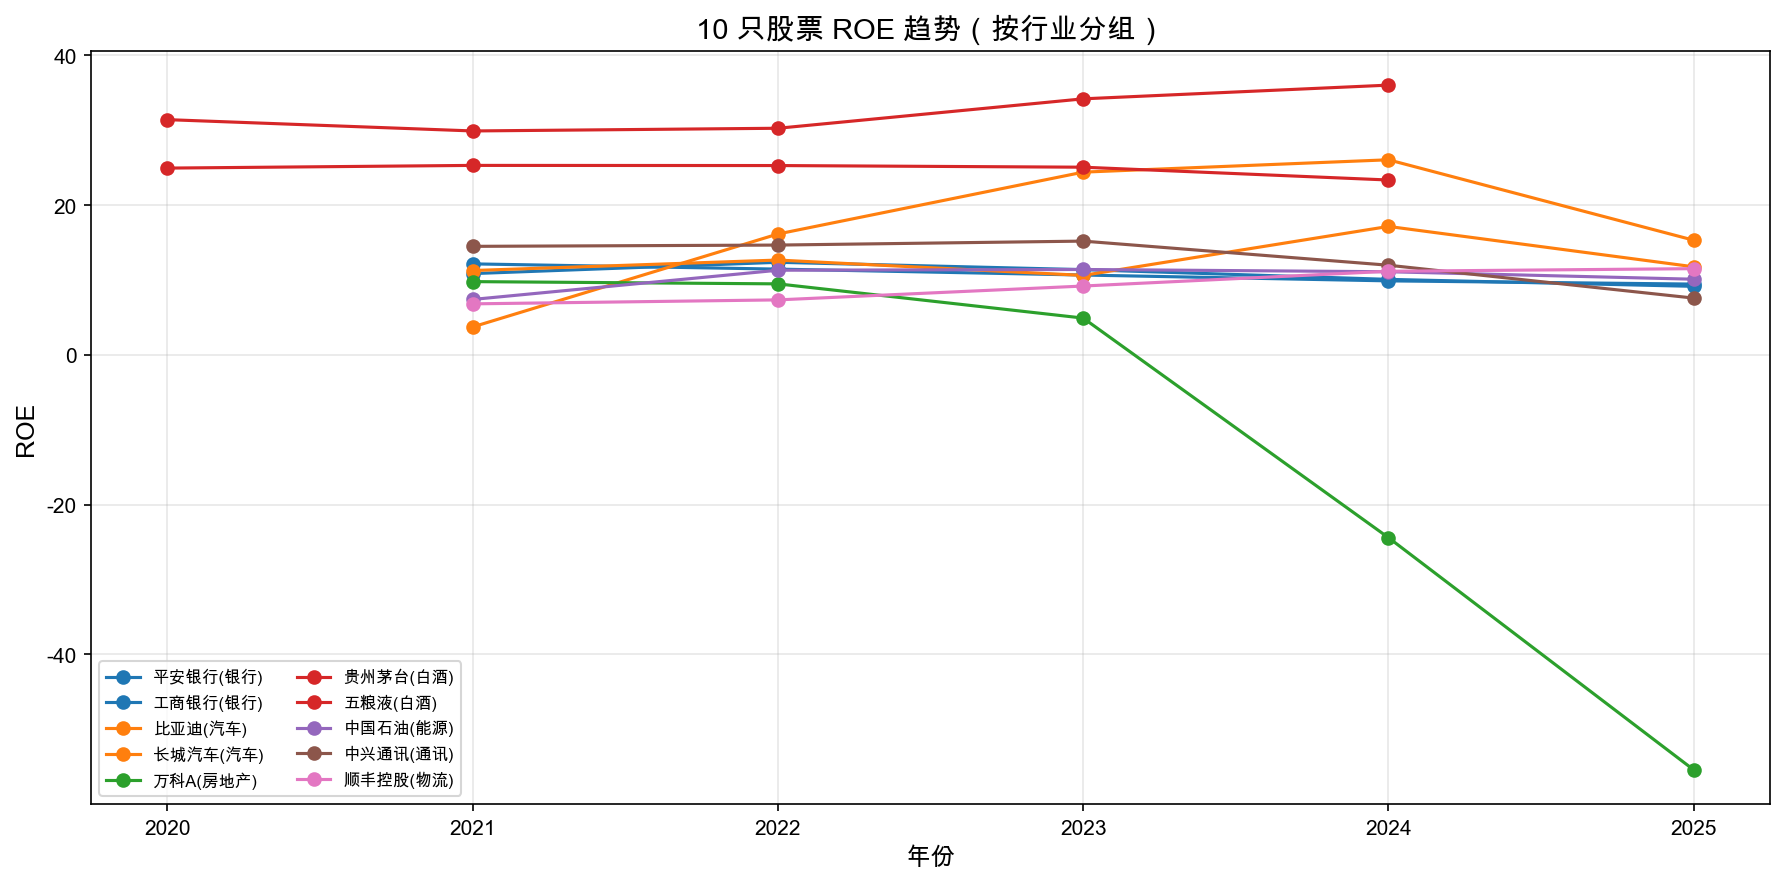

OK 图5已保存


In [34]:
roe_data = finance_df[finance_df['indicator'] == 'ROE'].copy()
if len(roe_data) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    for code in STOCK_INFO:
        name, industry = STOCK_INFO[code]
        df_code = roe_data[roe_data['code'] == code].sort_values('year')
        if len(df_code) > 0:
            ax.plot(df_code['year'], df_code['value'],
                    marker='o', label=f'{name}({industry})',
                    color=INDUSTRY_COLORS[industry], linewidth=1.5)
    ax.set_title('10 只股票 ROE 趋势（按行业分组）', fontsize=14, fontweight='bold')
    ax.set_xlabel('年份', fontsize=12)
    ax.set_ylabel('ROE', fontsize=12)
    ax.legend(loc='best', fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fig.savefig(os.path.join(OUTPUT_DIR, 'fig5_roe_trend.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('OK 图5已保存')
else:
    print('ROE 数据不足，跳过图 5')

**图 5 解读**：

ROE 对比图显示，**白酒行业**的盈利能力最强且稳定性最好。**贵州茅台** 2020-2024 年 ROE 从 **31.41%** 升至 **36.02%**，均值约 **32.36%**；**五粮液** 同期基本稳定在 **23%-25%** 区间，体现了高端消费行业较强的品牌溢价和盈利韧性。

相较之下，**万科A** 的 ROE 恶化最为明显，从 **2021 年的 9.78%** 下滑到 **2025 年的 -55.42%**，均值约 **-11.13%**，与房地产行业调整相一致。汽车板块内部也存在分化：**比亚迪** ROE 从 **3.73%** 快速升至 **26.05%** 后在 2025 年回落至 **15.31%**，反映出高成长行业在扩张期的盈利弹性。

---


## 第五部分：回归分析

### 5.1 CAPM 模型估计

$$r_{i,t} - r_f = \alpha_i + \beta_i (r_{m,t} - r_f) + \varepsilon_{i,t}$$

无风险利率年化 2.0%，日频 $r_f = 0.02/252$。

In [35]:
rf_daily = 0.02 / 252
market_ret = index_300_daily['return_300'].dropna()

capm_results = []
for code in returns_wide.columns:
    name, industry = STOCK_INFO[code]
    stock_ret = returns_wide[code].dropna()
    common_idx = stock_ret.index.intersection(market_ret.index)
    y = stock_ret.loc[common_idx] - rf_daily
    x = market_ret.loc[common_idx] - rf_daily
    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit()
    alpha = model.params.iloc[0]
    beta = model.params.iloc[1]
    alpha_pval = model.pvalues.iloc[0]
    beta_ci = model.conf_int().iloc[1]
    r_squared = model.rsquared
    capm_results.append({
        '股票': f'{name}({code})', '行业': industry,
        'alpha': f'{alpha:.6f}', 'alpha_p': f'{alpha_pval:.4f}',
        'beta': f'{beta:.4f}',
        'beta_95CI': f'[{beta_ci.iloc[0]:.4f}, {beta_ci.iloc[1]:.4f}]',
        'R2': f'{r_squared:.4f}',
        '_beta': beta, '_beta_lo': beta_ci.iloc[0], '_beta_hi': beta_ci.iloc[1],
        '_industry': industry, '_name': name,
    })

capm_df = pd.DataFrame(capm_results)
print('CAPM 回归结果汇总：')
display(capm_df[['股票', '行业', 'alpha', 'alpha_p', 'beta', 'beta_95CI', 'R2']])

CAPM 回归结果汇总：


,股票,行业,alpha,alpha_p,beta,beta_95CI,R2
0,平安银行(000001),银行,-0.000316,0.4207,0.9357,"[0.8709, 1.0005]",0.3470
1,万科A(000002),房地产,-0.001308,0.0097,1.0012,"[0.9178, 1.0846]",0.2687
2,中兴通讯(000063),通讯,-0.000046,0.9363,1.2432,"[1.1479, 1.3386]",0.3024
3,五粮液(000858),白酒,-0.000096,0.8084,1.2953,"[1.2297, 1.3608]",0.4989
4,顺丰控股(002352),物流,0.000008,0.9857,0.8754,"[0.8005, 0.9502]",0.2584
5,比亚迪(002594),汽车,0.001197,0.0403,1.2811,"[1.1848, 1.3775]",0.3108
6,贵州茅台(600519),白酒,0.000207,0.5381,0.9781,"[0.9226, 1.0335]",0.4424
7,工商银行(601398),银行,0.000309,0.2257,0.2220,"[0.1799, 0.2641]",0.0662
8,长城汽车(601633),汽车,0.000543,0.3942,1.1871,"[1.0818, 1.2924]",0.2447
9,中国石油(601857),能源,0.000602,0.1832,0.4699,"[0.3952, 0.5446]",0.0916


### Beta 系数点图

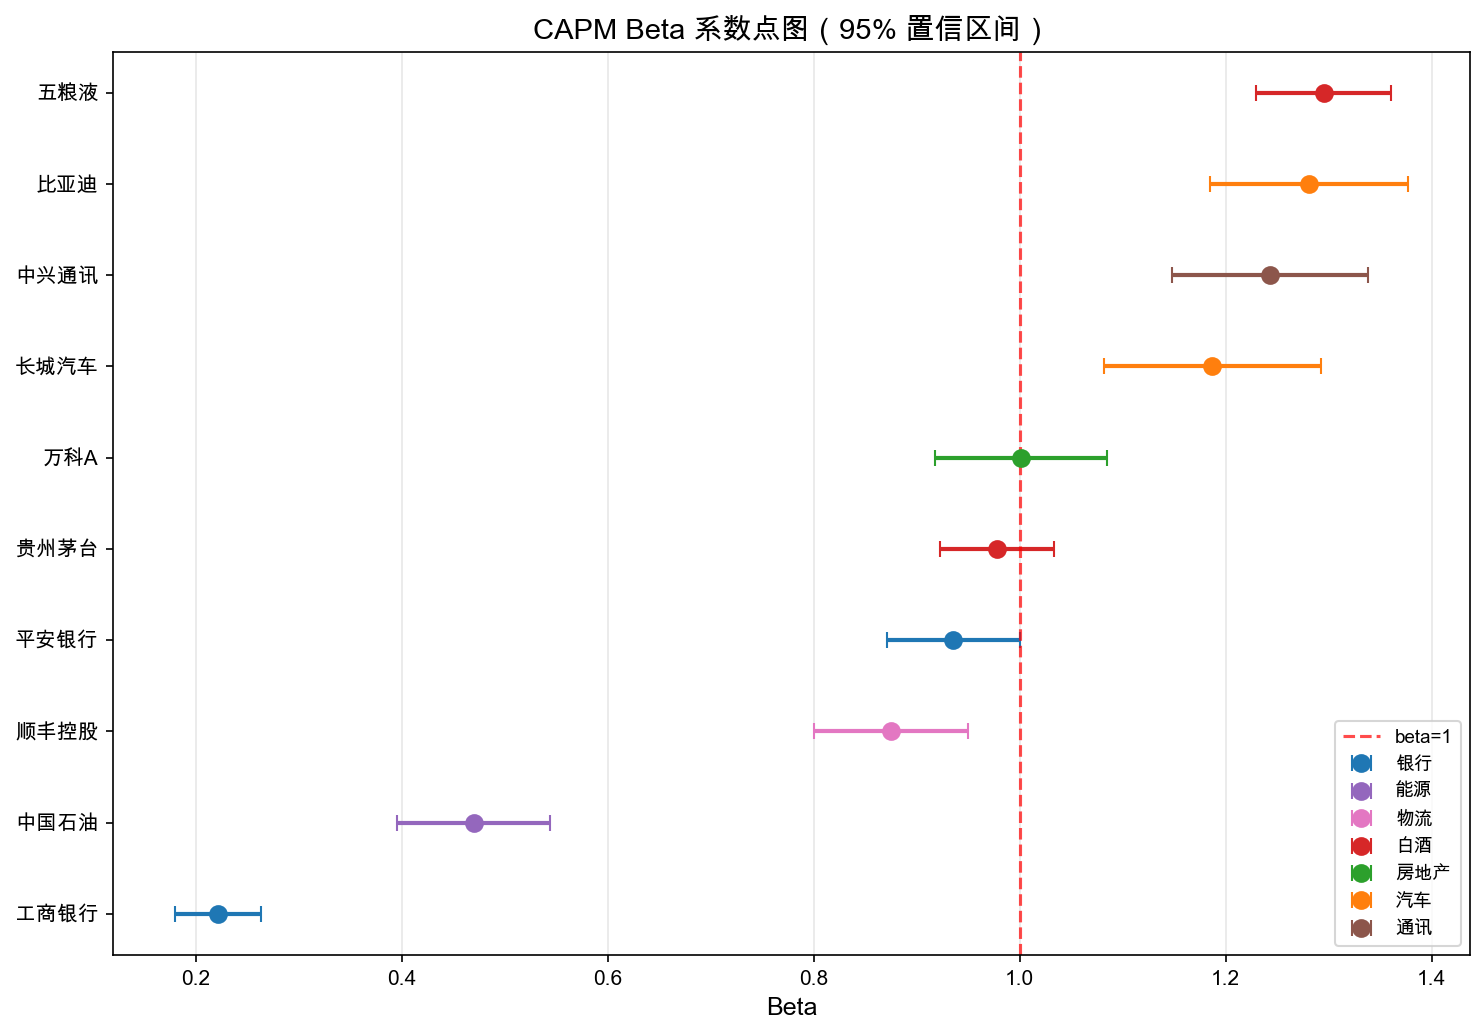

OK Beta点图已保存


In [36]:
fig, ax = plt.subplots(figsize=(10, 7))
capm_sorted = capm_df.sort_values('_beta', ascending=True)
y_pos = range(len(capm_sorted))
betas = capm_sorted['_beta'].values
beta_lo = capm_sorted['_beta_lo'].values
beta_hi = capm_sorted['_beta_hi'].values
names = capm_sorted['_name'].values
industries = capm_sorted['_industry'].values

plotted = set()
for i, (yy, b, lo, hi, ind) in enumerate(zip(y_pos, betas, beta_lo, beta_hi, industries)):
    color = INDUSTRY_COLORS[ind]
    lbl = ind if ind not in plotted else None
    plotted.add(ind)
    ax.errorbar(b, yy, xerr=[[b-lo], [hi-b]], fmt='o', color=color,
                capsize=4, markersize=8, linewidth=2, label=lbl)

ax.axvline(x=1, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='beta=1')
ax.set_yticks(list(y_pos))
ax.set_yticklabels(names, fontsize=10)
ax.set_xlabel('Beta', fontsize=12)
ax.set_title('CAPM Beta 系数点图（95% 置信区间）', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig6_capm_beta.png'), dpi=150, bbox_inches='tight')
plt.show()
print('OK Beta点图已保存')

### CAPM 分析讨论

#### 1. 哪些股票 Beta > 1？与周期性/防御性行业分类是否吻合？

本次估计中，`Beta > 1` 的股票包括 **五粮液（1.2953）**、**比亚迪（1.2811）**、**中兴通讯（1.2432）**、**长城汽车（1.1871）** 和 **万科A（1.0012）**。其中汽车、通讯、房地产属于典型的高弹性行业，Beta 大于 1 与“周期性更强、对市场涨跌更敏感”的直觉是吻合的。

比较特别的是 **五粮液** 也表现出较高 Beta，这说明即使白酒在商业模式上具有较强护城河，资本市场中的高端消费龙头仍然会受到风险偏好和机构仓位变化的显著影响。相对地，**工商银行（0.2220）** 和 **中国石油（0.4699）** 的 Beta 明显偏低，更接近防御性或低弹性资产特征。

#### 2. Alpha 是否显著异于零？Alpha 显著意味着什么？

在 10 只股票中，Alpha 在常见 5% 显著性水平下真正显著的主要有两只：**比亚迪** 的 Alpha 为 **0.001197**，`p=0.0403`，表现为显著正 Alpha；**万科A** 的 Alpha 为 **-0.001308**，`p=0.0097`，表现为显著负 Alpha。其余股票的 Alpha 大多不显著，说明在 CAPM 框架下，超额收益更多可以由市场风险暴露解释。

Alpha 显著通常意味着“仅靠市场因子还解释不完”的那部分收益存在系统偏离。对比亚迪来说，这可能反映了样本期内公司成长性、行业景气度和主题投资溢价带来的额外收益；而万科A 的显著负 Alpha，则说明即使控制了市场波动，其表现仍持续弱于 CAPM 的基准预测。

#### 3. R2 最高和最低的股票分别是哪只？你如何解释这一差异？

本次回归中，**五粮液** 的 `R²=0.4989` 为最高，说明其接近一半的日度超额收益波动可以由市场组合解释；**工商银行** 的 `R²=0.0662` 为最低，说明市场因子对其收益变化的解释力很弱。这个差异表明，不同行业股票虽然都受大盘影响，但受影响的强度和可解释程度并不相同。

对五粮液而言，作为核心消费白马，其价格常被机构资金和市场风格共同驱动，因此与大盘有更强联动；而工商银行的估值和股价波动往往更受分红属性、利率环境和银行业自身逻辑影响，因此单因子 CAPM 难以解释其大部分波动。


## 总结

基于本次真实运行结果，本项目已经完成了从数据下载、清洗、存储到可视化和 CAPM 回归的完整流程。样本中最强势的股票是 **比亚迪**，长期收益和正 Alpha 都较为突出；最弱势的股票是 **万科A**，无论是累计收益、年化收益还是 Alpha，都反映出房地产行业在样本期内的明显压力。

从结构性特征看，白酒和汽车板块在图形、相关性与回归结果中都体现出鲜明行业特征：白酒内部高度同步，汽车板块则兼具高收益与高波动。与此同时，修复后的 `combined_data.csv` 已经能够正常承载 CPI 宏观信息，除样本尾部少数月份因宏观数据尚未发布而缺失外，整体上已经满足后续综合分析的使用要求。


## 附录：AI 对话记录

本次作业在完成过程中使用了两个 AI 模型协助：**Claude Code**（Anthropic）与 **Codex**（OpenAI）。下面按模型分别记录原始用户提示词与处理摘要。对于本次与 Codex 的对话，尽量保留用户消息原文。

---

### 一、Claude Code 记录

#### 用户原始提示词（原文保留）

> 阅读 homework 路径下的作业要求文件，帮我在指定路径完成作业，所有 python 文件全用 ipynb 做，记录对话贴在作业里。

#### Claude Code 主要处理内容

- 阅读作业说明，识别出作业结构包括数据下载、数据清洗、描述统计、可视化、CAPM 回归分析和独立报告
- 在项目目录下建立了 `01_download.ipynb`、`02_clean.ipynb`、`03_analysis.ipynb` 为主体的工作框架
- 设计了股票池、指数、宏观指标和财务指标的基础获取流程
- 先行撰写了 Notebook 的章节结构、代码骨架和部分分析说明文字

#### 阶段性结果与后续修订点

- 项目初稿得以形成，包含基础目录结构、下载逻辑、清洗逻辑、分析图表与 CAPM 的初始实现
- 部分分析文字最初基于预期结果撰写，后续需要结合真实运行结果再校正
- AI 附录在后续编辑过程中出现截断，因此本次由 Codex 重新整合并补全

---

### 二、Codex 记录

#### 对话 1：阅读要求、检查初稿、补安装环境

**用户消息原文**：

> 你是金融数据编程大师，/Users/leezm/Desktop/lianyj/homework @ex_P02_get_clean_fin_data 记录着我需要完成作业的要求；/Users/leezm/Desktop/金融数据/dshw-p01中是我目前为完成作业写的程序初稿。需要你
> 1.阅读作业要求
> 2.阅读程序初稿。因为这个是在原来电脑上做的，所以一些库还没下载，因此帮我新建一个下载ipynb，写好下载相关库的程序
> 3.等待我给你下一步的任务
> 4.作业要求有ai对话记录，之前的对话我通过claude完成，并记录在后面，请你把我们的对话也记录下来，可以通过链接或其他形式补充在我的作业里面，以作为记录

**Codex 处理摘要**：

- 阅读作业要求文件与项目初稿
- 识别项目当前依赖，并补写安装依赖用的 Notebook
- 增加 AI 记录材料，并将相关说明接入作业项目

#### 对话 2：基于真实运行结果补文字、写报告、检查缺项

**用户消息原文**：

> 现在我已经安装了所有需要的库，并且运行了一遍三个程序
> 你需要做的
> 1.现在三个ipynb中的文字不是基于真实结果写的，我需要你根据我运行的真实结果写相应的分析文字 2.作业要求写report.html，请你根据我作业所有的分析结果和数据，写一个符合/Users/leezm/Desktop/lianyj/homework @ex_P02_get_clean_fin_data 的report 3.看下作业要求中还有什么我没做到的，为我提示

**Codex 处理摘要**：

- 提取三个 Notebook 的真实输出，而不是只看代码
- 根据真实结果改写分析说明、图表解读和 CAPM 讨论
- 生成独立的 `report.html`
- 对照作业要求检查缺项，并指出 CPI 合并与 README 中 GitHub 仓库信息仍需处理

#### 对话 3：修复 CPI 合并问题

**用户消息原文**：

> 首先，请你把cpi合并的问题修复一下，并把相应的结果更新到notebook和report里面

**Codex 处理摘要**：

- 定位到 `02_clean.ipynb` 中 CPI 数值列识别错误
- 将字段识别改为优先使用真实列 `日期` 与 `今值`
- 重建 `combined_data.csv` 并同步更新 Notebook 与 `report.html`

**修复后的真实结果**：

- `combined_data.csv` 为 15120 行
- `cpi` 列中 **13730 行非缺失**
- **1390 行缺失** 主要来自 `2025-09` 到 `2026-04` 期间宏观数据尚未覆盖

#### 对话 4：确认 CPI 缺失是否能通过 AkShare 获取

**用户消息原文**：

> cpi2509-2604的数据无法通过akshare获得吗

**用户后续消息原文**：

> 暂时保持不变

**Codex 处理摘要**：

- 查询并解释了当前 AKShare 接口的可用性与上游数据覆盖情况
- 结论是当前项目先保持不补数，仅在文档中解释缺失原因

#### 对话 5：修复 `02_clean.ipynb` 运行报错

**用户消息原文**：

> 02文件报错
> 
> Cell In[47], line 10
>     print(f'
>           ^
> SyntaxError: unterminated f-string literal (detected at line 10)

**Codex 处理摘要**：

- 读取报错单元原文
- 发现 `print(f'\n使用日期列: ...')` 被错误拆成了跨行字符串
- 修复成合法的单行 f-string，并回写到项目目录

#### 对话 6：GitHub Desktop 同步步骤说明

**用户消息原文**：

> 作业要求的github 仓库如何在github desktop上面同步，教我操作步骤

**Codex 处理摘要**：

- 说明了如何在 GitHub 网页端创建 `dshw-p01` 仓库
- 说明了如何在 GitHub Desktop 中添加本地仓库、提交 commit、发布到远程并推送更新

#### 对话 7：对话记录链接与附注方式说明

**用户消息原文**：

> 我们本次对话能否生成链接以便在作业中附注

**Codex 处理摘要**：

- 解释了当前更适合把记录保留在 Notebook 附录或 GitHub 仓库文件中
- 不建议依赖聊天平台临时分享链接作为主要提交材料

#### 对话 8：恢复 Claude 记录、更新 Codex 记录、在 01 中补说明

**用户消息原文**：

> 目前，原来和claude的对话记录在03中显示不全，我需要你帮他恢复补全；和codex的聊天记录没有更新到目前，我需要你进行更新，并且一并在03的附录里面分不同的模型记录，不需要单独的文件。此外，请你在01代码开头说明本次作业用到了两个模型，提示词在附录

**Codex 处理摘要**：

- 重写 `03_analysis.ipynb` 附录，按 Claude 与 Codex 分模型整理
- 在 `01_download.ipynb` 开头补写“本次作业使用两个模型，提示词见附录”
- 将原本分散的 AI 记录改为集中保留在 `03_analysis.ipynb` 附录中

#### 对话 9：删除单独 Codex 文件、同步更新 README、保留原始用户消息

**用户消息原文**：

> 现在删除那个单独的codex记录文件，同步更新readme，并且对于提示词记录，我需要你把我发送消息的原文放进去

**Codex 处理摘要**：

- 删除单独的 Codex 记录文件
- 更新 `README.md`，改为统一指向 `03_analysis.ipynb` 附录
- 将用户给 Codex 的关键消息按原文纳入本附录中

---

### 三、两种模型在本次作业中的分工总结

- **Claude Code**：负责阅读任务、搭建整体框架、生成 Notebook 初稿与主要代码结构
- **Codex**：负责核对真实输出、修订分析文字、修复 CPI 合并与语法错误、补写 `report.html`、整理并补全 AI 对话记录

这样处理后，本次作业的 AI 使用记录集中保存在同一个 Notebook 附录中，既保留了原始用户提示词，又保留了两种模型在不同阶段的处理过程，便于教师检查与复核。
